In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib


In [6]:
# Load your dataset
df = pd.read_csv("C:/Users/M Sarmad Usman/Desktop/heart_disease_uci.csv")
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
# Overview
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Missing values
print(df.duplicated().sum())  # Duplicates


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  

In [8]:
# Fill numeric columns with median
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
cat_cols = ['fbs', 'exang', 'slope', 'thal', 'restecg']
for col in cat_cols:
    if df[col].mode().empty:
        print(f"⚠️ Skipping mode fill for {col}")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Drop any remaining missing values if necessary
df.dropna(inplace=True)

print(df.isnull().sum())  # Check again


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


C:\Users\M Sarmad Usman\AppData\Local\Temp\ipykernel_3300\111084225.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [9]:
label_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [10]:
df.drop(['id'], axis=1, inplace=True)


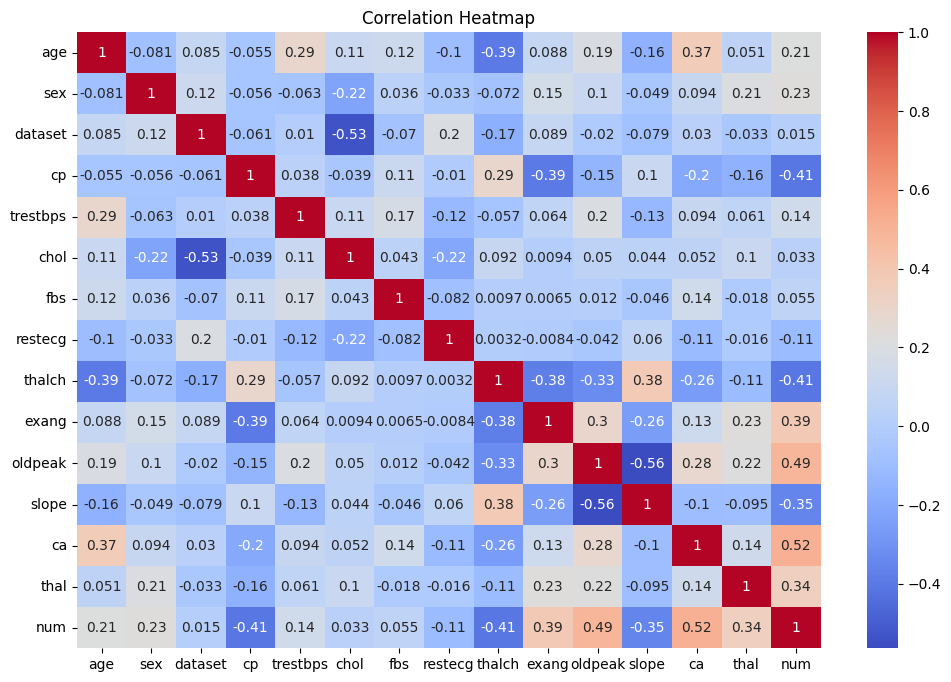

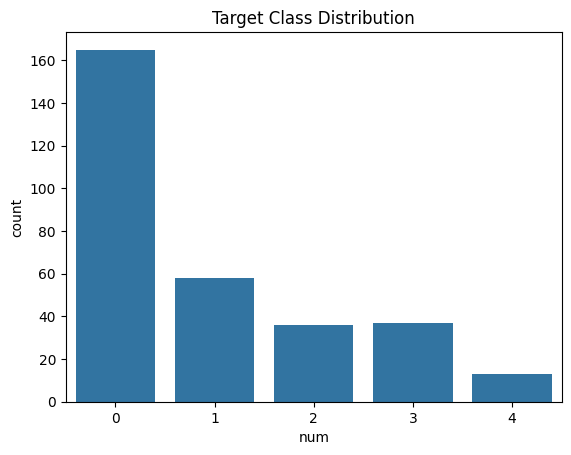

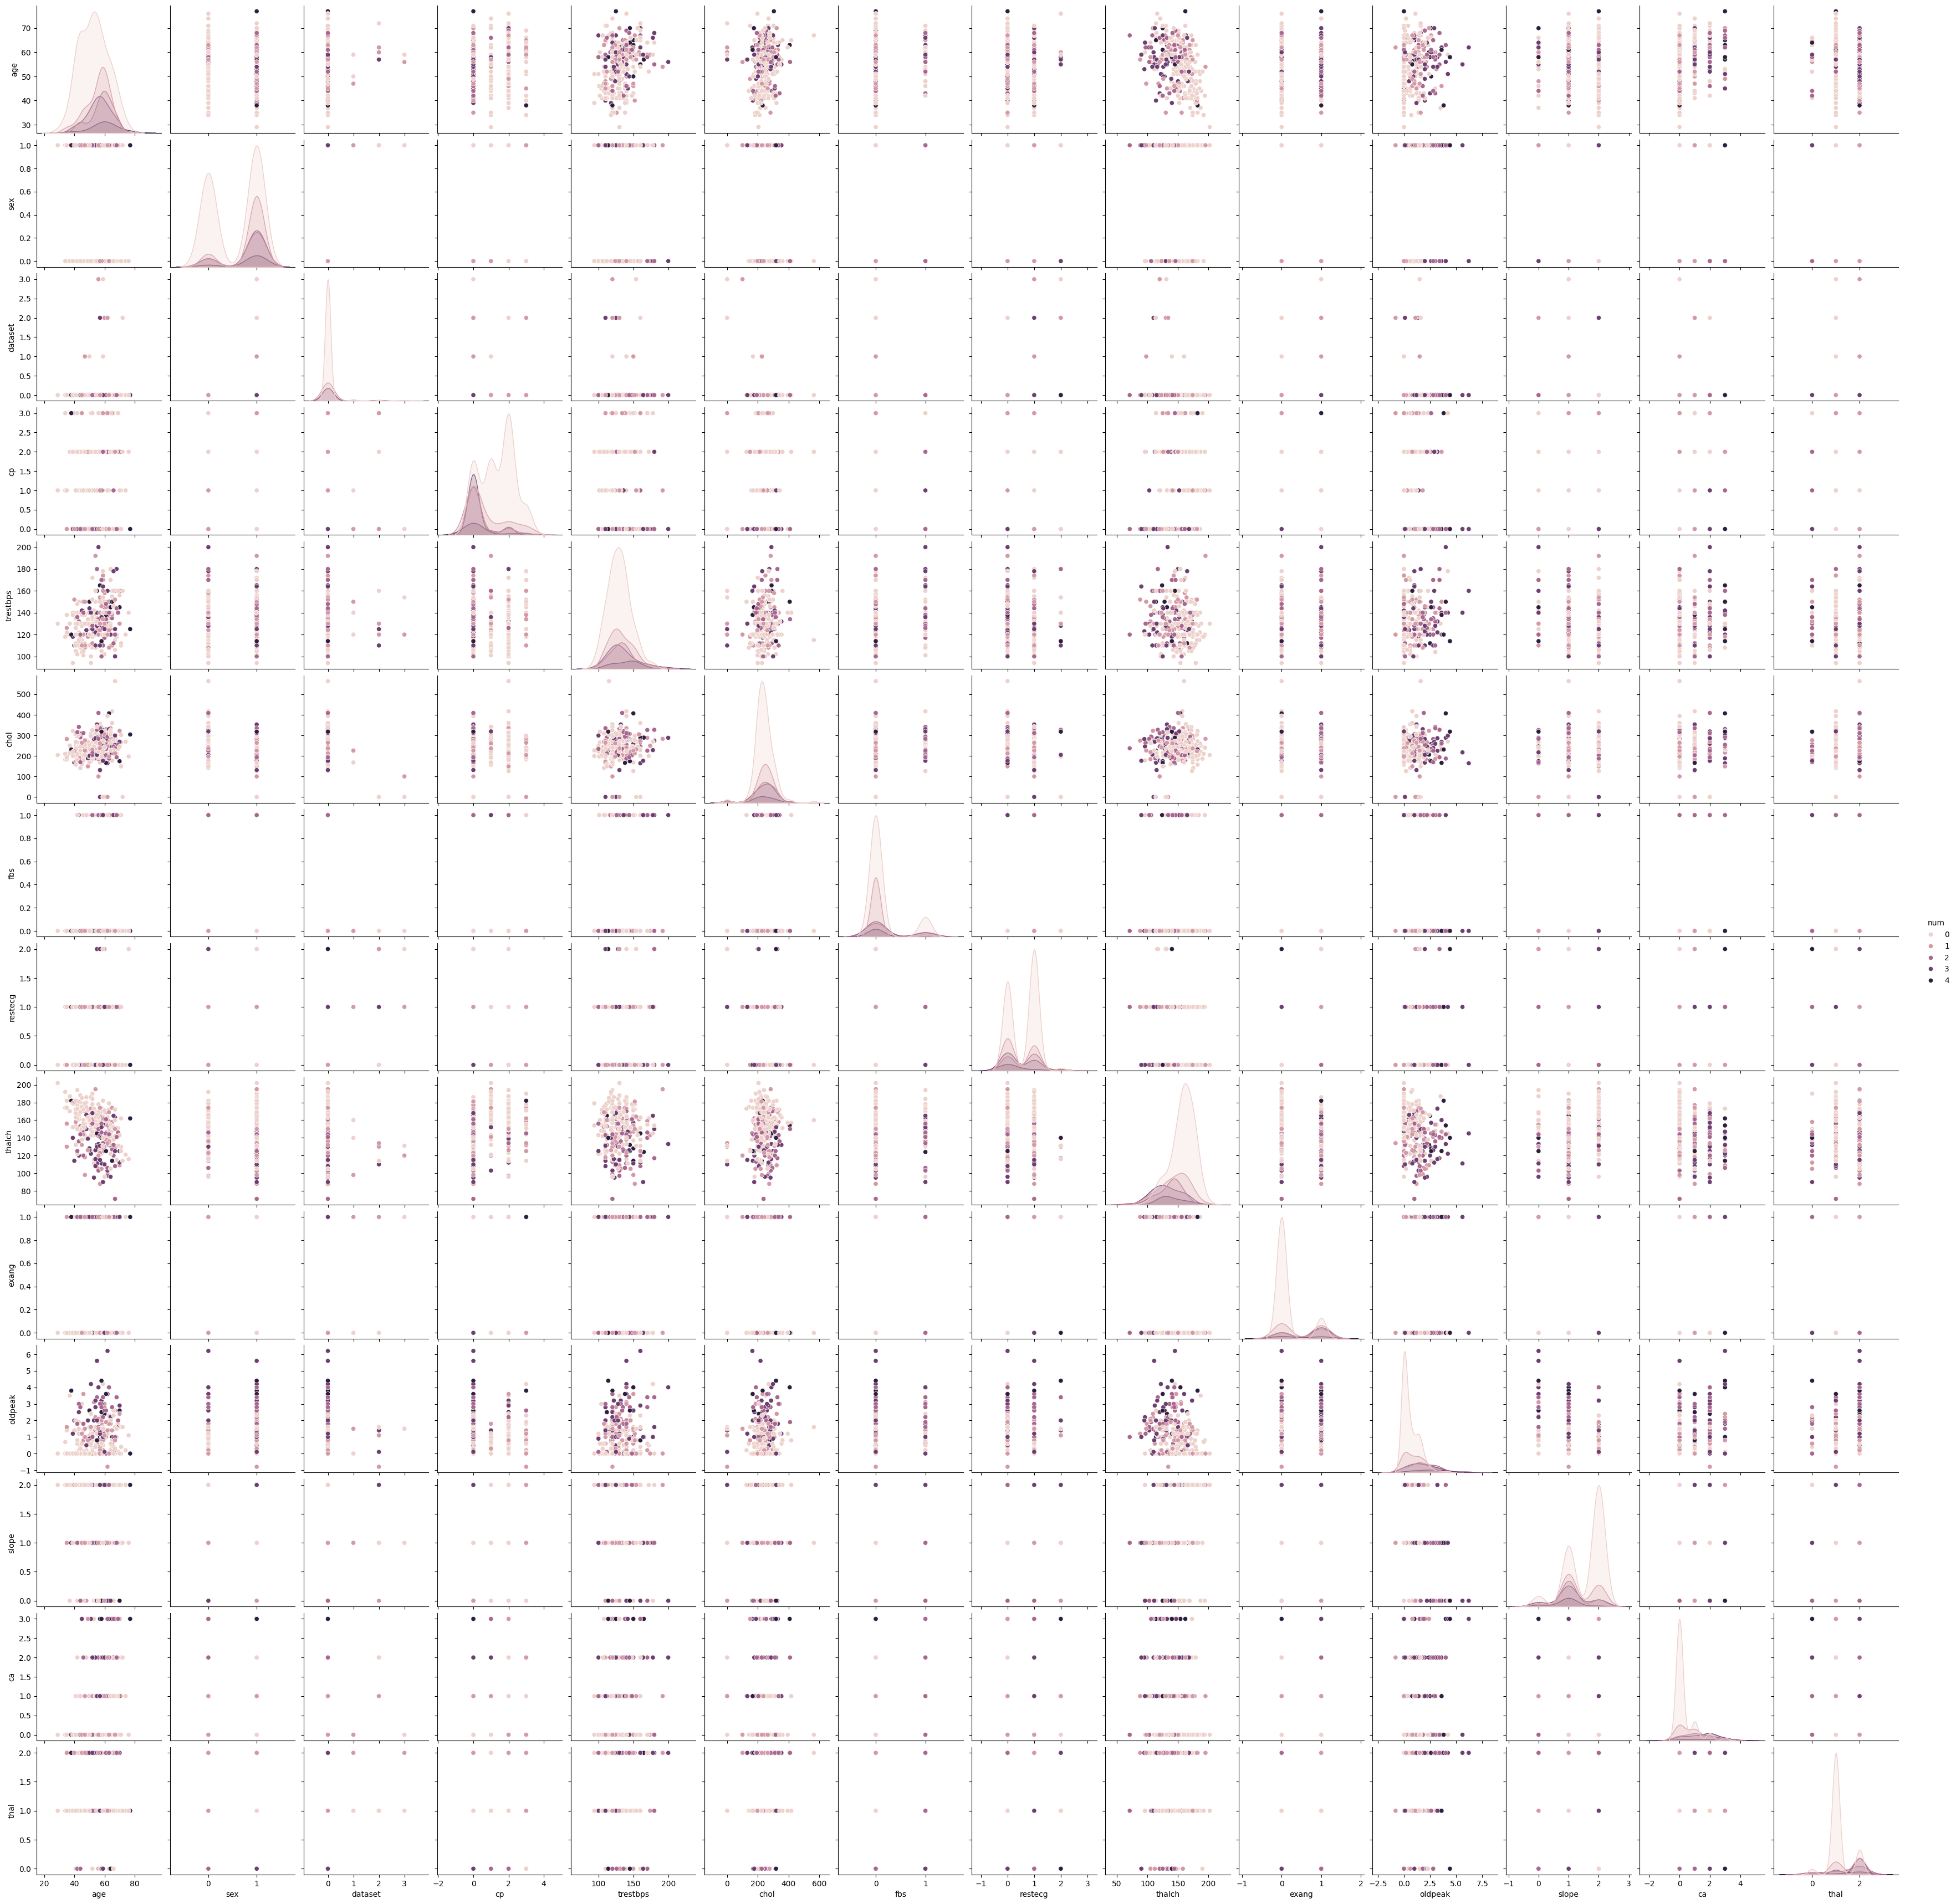

In [11]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Class distribution
sns.countplot(data=df, x="num")
plt.title("Target Class Distribution")
plt.show()

# Pairplot
sns.pairplot(df, hue="num")
plt.show()


In [12]:
X = df.drop("num", axis=1)
y = df["num"]

# Binary target (convert >0 to 1)
y = y.apply(lambda x: 1 if x > 0 else 0)


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for Streamlit
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
# Save test data for real-time evaluation in Streamlit
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_test.pkl')



['y_test.pkl']

In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("🔍 Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))
print("✅ Accuracy:", accuracy_score(y_test, y_pred_log))

joblib.dump(log_model, "logistic_model.pkl")


🔍 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.88      0.79      0.84        29

    accuracy                           0.85        62
   macro avg       0.86      0.85      0.85        62
weighted avg       0.86      0.85      0.85        62

✅ Accuracy: 0.8548387096774194


['logistic_model.pkl']

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("🔍 Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("✅ Accuracy:", accuracy_score(y_test, y_pred_rf))

joblib.dump(rf_model, "rf_model.pkl")


🔍 Random Forest Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.85      0.76      0.80        29

    accuracy                           0.82        62
   macro avg       0.83      0.82      0.82        62
weighted avg       0.82      0.82      0.82        62

✅ Accuracy: 0.8225806451612904


['rf_model.pkl']

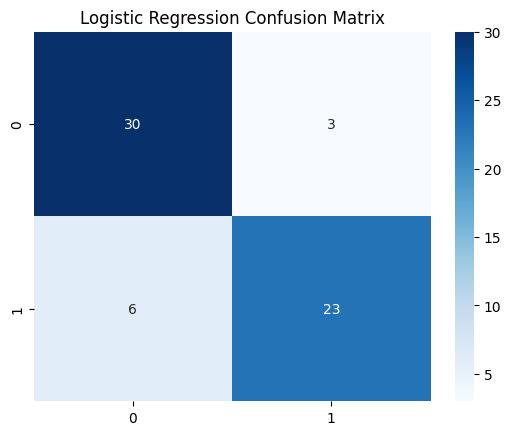

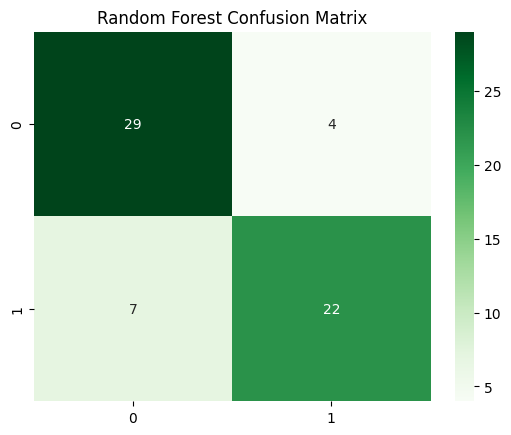

In [17]:
# Logistic Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()


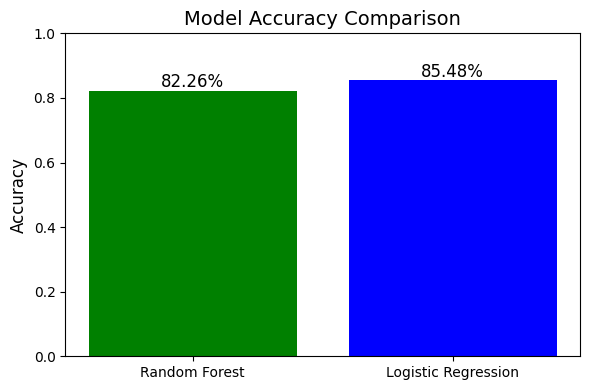

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Replace with actual accuracy values
rf_acc = accuracy_score(y_test, y_pred_rf)
lr_acc = accuracy_score(y_test, y_pred_log)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Random Forest', 'Logistic Regression'], [rf_acc, lr_acc], color=['green', 'blue'])

# Title and labels
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)

# Annotate bars with exact accuracy values
plt.text(0, rf_acc + 0.01, f'{rf_acc:.2%}', ha='center', fontsize=12)
plt.text(1, lr_acc + 0.01, f'{lr_acc:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


In [19]:
import joblib

# Save the scaler and models
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(log_model, 'logistic_regression_model.pkl')


['logistic_regression_model.pkl']